In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from numpy.random import seed
from sklearn.preprocessing import minmax_scale
from sklearn.model_selection import train_test_split


In [4]:
#from __future__ import print_function
import keras
from keras.models import Sequential
from keras.layers import Dense, Dropout, Flatten
from keras.layers import Conv2D, MaxPooling2D
from keras.callbacks import ModelCheckpoint
from keras.models import model_from_json
from keras import backend as K
from keras.layers import Input, Dense, Conv2D, MaxPooling2D, UpSampling2D, Flatten, Reshape
from keras.models import Model


In [229]:
inp_file=input("Enter the file name:")

Enter the file name:kdd_test_prep2.csv


In [250]:
encoding_dim=int(input("Enter the features dim:"))

Enter the features dim:16


In [251]:
kdd_FE= pd.read_csv(str(inp_file))

In [252]:
kdd_FE.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22544 entries, 0 to 22543
Columns: 110 entries, duration to label_5
dtypes: float64(107), object(3)
memory usage: 18.9+ MB


In [253]:
kdd_FE.head()

,duration,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,...,flag_RSTR,flag_S0,flag_S1,flag_S2,flag_S3,flag_SF,flag_SH,attack,label_2,label_5
0,0.000000,0.000000e+00,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,neptune,attack,DoS
1,0.000000,0.000000e+00,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,neptune,attack,DoS
2,0.000035,2.066513e-04,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,normal,normal,Normal
3,0.000000,3.183413e-07,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,saint,attack,Probe
4,0.000017,0.000000e+00,0.000011,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,mscan,attack,Probe


kdd_FE=kdd_FE[kdd_FE['Anomaly']==-1]

In [254]:
label_list=[ 'attack','label_2','label_5']
kdd_FE_label=kdd_FE[label_list]
print(kdd_FE_label.head())
print("kdd_train_label:", kdd_FE_label.shape)

    attack label_2 label_5
0  neptune  attack     DoS
1  neptune  attack     DoS
2   normal  normal  Normal
3    saint  attack   Probe
4    mscan  attack   Probe
kdd_train_label: (22544, 3)


In [255]:
kdd_FE.drop(label_list, axis = 1, inplace = True)

In [256]:
# define the number of features
ncol = kdd_FE.shape[1]
print(ncol)

107


#### Split train data into train and validation 70:30 in ratio

In [257]:
X_train, X_val,y_train, y_val = train_test_split(kdd_FE,kdd_FE_label['label_2'], train_size = 0.7, test_size = 0.3, random_state = seed(100))

In [258]:
X_train.head()

,duration,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,num_failed_logins,logged_in,num_compromised,...,flag_REJ,flag_RSTO,flag_RSTOS0,flag_RSTR,flag_S0,flag_S1,flag_S2,flag_S3,flag_SF,flag_SH
20743,0.0,6.525997e-07,0.000097,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
12843,0.0,4.838788e-06,0.005496,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
18760,0.0,0.000000e+00,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
14401,0.0,4.600032e-06,0.015695,0.0,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
6537,0.0,8.754386e-07,0.000040,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [259]:
y_train.head()

20743    normal
12843    normal
18760    attack
14401    normal
6537     normal
Name: label_2, dtype: object

In [260]:
X_train.shape

(15780, 107)

In [261]:
X_val.shape

(6764, 107)

In [262]:
### Define the encoder dimension
#encoding_dim = 50


In [263]:
input_dim = Input(shape = (ncol, ))

# Encoder Layers
encoded = Dense(100, activation = 'elu')(input_dim)
encoded = Dense(64, activation = 'elu')(encoded)
encoded = Dense(32, activation = 'elu')(encoded)
encoded = Dense(encoding_dim, activation = 'tanh')(encoded)

# Decoder Layer
decoded = Dense(32, activation = 'elu')(encoded)
decoded = Dense(64, activation = 'elu')(encoded)
decoded = Dense(100, activation = 'elu')(decoded)
decoded = Dense(ncol, activation = 'tanh')(decoded)

# Combine Encoder and Deocder layers
autoencoder = Model(inputs = input_dim, outputs = decoded)

# Compile the Model
autoencoder.compile(optimizer = 'adam', loss = 'mse')

In [264]:
print(autoencoder.summary())

_________________________________________________________________
Layer (type)                 Output Shape              Param #   
input_25 (InputLayer)        (None, 107)               0         
_________________________________________________________________
dense_97 (Dense)             (None, 100)               10800     
_________________________________________________________________
dense_98 (Dense)             (None, 64)                6464      
_________________________________________________________________
dense_99 (Dense)             (None, 32)                2080      
_________________________________________________________________
dense_100 (Dense)            (None, 16)                528       
_________________________________________________________________
dense_102 (Dense)            (None, 64)                1088      
_________________________________________________________________
dense_103 (Dense)            (None, 100)               6500      
__________

### Train Auto Encoder

### final autoencoder with epochs=  batch_size=

In [265]:

import time
start_time= time.time()
history=autoencoder.fit(X_train, X_train, epochs = 20, batch_size = 100, shuffle = False, validation_data = (X_val, X_val))
print("\n\nRun Time ->","--- %s seconds ---" % (time.time() - start_time))


Train on 15780 samples, validate on 6764 samples
Epoch 1/20
15780/15780 [==============================] - 2s 139us/step - loss: 0.0164 - val_loss: 0.0070
Epoch 2/20
15780/15780 [==============================] - 1s 63us/step - loss: 0.0056 - val_loss: 0.0043
Epoch 3/20
15780/15780 [==============================] - 1s 62us/step - loss: 0.0039 - val_loss: 0.0034
Epoch 4/20
15780/15780 [==============================] - 1s 62us/step - loss: 0.0033 - val_loss: 0.0030
Epoch 5/20
15780/15780 [==============================] - 1s 63us/step - loss: 0.0029 - val_loss: 0.0027
Epoch 6/20
15780/15780 [==============================] - 1s 62us/step - loss: 0.0027 - val_loss: 0.0025
Epoch 7/20
15780/15780 [==============================] - 1s 63us/step - loss: 0.0025 - val_loss: 0.0023
Epoch 8/20
15780/15780 [==============================] - 1s 63us/step - loss: 0.0023 - val_loss: 0.0022
Epoch 9/20
15780/15780 [==============================] - 1s 63us/step - loss: 0.0022 - val_loss: 0.0021
Epoch

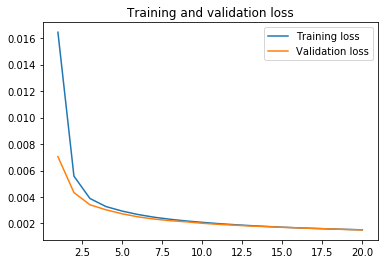

In [266]:
loss = history.history['loss']
val_loss = history.history['val_loss']
n_epoch = range(1,21,1)
plt.figure()
plt.plot(n_epoch, loss, label='Training loss')
plt.plot(n_epoch, val_loss, label='Validation loss')
plt.title('Training and validation loss')
plt.legend()
plt.show()

### Use Encoder level to reduce dimension of train and test data

In [267]:
encoder = Model(inputs = input_dim, outputs = encoded)
encoded_input = Input(shape = (encoding_dim, ))


In [268]:
encoder.summary()

_________________________________________________________________
Layer (type)                 Output Shape              Param #   
input_25 (InputLayer)        (None, 107)               0         
_________________________________________________________________
dense_97 (Dense)             (None, 100)               10800     
_________________________________________________________________
dense_98 (Dense)             (None, 64)                6464      
_________________________________________________________________
dense_99 (Dense)             (None, 32)                2080      
_________________________________________________________________
dense_100 (Dense)            (None, 16)                528       
Total params: 19,872
Trainable params: 19,872
Non-trainable params: 0
_________________________________________________________________


### Predict the new train and test data using Encoder

In [269]:
import time
start_time= time.time()
encoded_df = pd.DataFrame(encoder.predict(kdd_FE))
encoded_df = encoded_df.add_prefix('feature_')
print("\n\nRun Time ->","--- %s seconds ---" % (time.time() - start_time))


#encoded_test = pd.DataFrame(encoder.predict(X_test))
#encoded_test = encoded_test.add_prefix('feature_')



Run Time -> --- 1.1457428932189941 seconds ---


In [227]:
encoded_df = pd.concat([encoded_df,kdd_FE_label], axis = 1)
encoded_df.head()

,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,feature_10,feature_11,feature_12,feature_13,feature_14,feature_15,attack,label_2,label_5
0,-0.610297,0.015690,0.244284,0.352685,0.098303,0.051206,0.565619,-0.170327,-0.480295,0.511890,-0.345204,-0.250245,0.153789,0.130684,-0.366019,-0.346800,normal,normal,Normal
1,-0.320410,0.225044,0.196418,-0.384782,0.432065,0.406117,0.382799,0.559387,-0.519859,-0.177010,-0.744206,-0.138820,-0.454535,0.392853,0.114113,0.263252,normal,normal,Normal
2,-0.210319,-0.071026,-0.171084,-0.365576,-0.110040,-0.556858,-0.402690,0.084723,-0.611879,0.180987,0.096818,-0.182270,0.125826,-0.161087,0.018053,-0.070685,neptune,attack,DoS
3,-0.441471,0.564467,0.409880,0.100402,0.048755,-0.295237,0.259262,0.316889,0.427560,0.090939,0.158640,0.115799,0.299643,0.295627,-0.219365,-0.127189,normal,normal,Normal
4,-0.478021,0.467679,0.487976,0.169325,0.023414,-0.274954,0.272012,0.305004,0.447077,-0.031349,0.182356,0.156464,0.240549,0.295723,-0.003924,-0.067834,normal,normal,Normal


In [228]:
encoded_df.shape

(125973, 19)

In [ ]:
encoded_df.head()

In [ ]:
#encoded_train.to_csv('kdd_train_FE.csv',index=False)

In [ ]:
out_file=inp_file.split(".")[0] + "_AER_"+str(encoding_dim)+".csv"

In [ ]:
print(out_file)

In [ ]:
encoded_df.to_csv(out_file,index=False)